## Import required libraries

In [ ]:
!pip install opencv-python

In [ ]:
!pip install tensorflow

In [ ]:
!pip install keras

In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import tensorflow.keras.utils as utils
from tensorflow.keras.utils import to_categorical

## Build function to load the data

In [ ]:
# ---------- Load Train Function (expects subfolders for each class) ----------
def load_data(data_dir, img_size=64, grayscale=True):
    data = []
    labels = []
    classes = sorted(os.listdir(data_dir))

    for label, class_name in enumerate(classes):
        path = os.path.join(data_dir, class_name)
        for img_name in os.listdir(path):
            try:
                if grayscale:
                    img = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_GRAYSCALE)
                    img = cv2.resize(img, (img_size, img_size))
                    img = img / 255.0
                    img = np.expand_dims(img, axis=-1)
                else:
                    img = cv2.imread(os.path.join(path, img_name))
                    img = cv2.resize(img, (img_size, img_size))
                    img = img / 255.0
                data.append(img)
                labels.append(label)
            except:
                pass
    return np.array(data, dtype="float32"), np.array(labels), classes



In [ ]:
# ---------- Load Test Function (reads images directly, no subfolders) ----------
def load_test(data_dir, img_size=64, grayscale=True):
    data = []
    file_names = []

    for img_name in os.listdir(data_dir):
        path = os.path.join(data_dir, img_name)
        try:
            if grayscale:
                img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (img_size, img_size))
                img = img / 255.0
                img = np.expand_dims(img, axis=-1)
            else:
                img = cv2.imread(path)
                img = cv2.resize(img, (img_size, img_size))
                img = img / 255.0
            data.append(img)
            file_names.append(img_name)
        except:
            pass

    return np.array(data, dtype="float32"), file_names

In [ ]:
#connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ---------- Paths ----------
Train_DIR = "/content/drive/MyDrive/ASL Dataset/ASL_Alphabet_Dataset/asl_alphabet_train"
Test_DIR  = "/content/drive/MyDrive/ASL Dataset/ASL_Alphabet_Dataset/asl_alphabet_test"

In [ ]:
# ---------- Load Data ----------
X_train, y_train, classes = load_data(Train_DIR, grayscale=True)
X_test, test_files= load_test(Test_DIR, grayscale=True)

In [ ]:
# --- هنا نعمل One-Hot Encoding for y_train only because test data doesn't have labels ---
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, num_classes=len(classes))

In [ ]:
# shape of data before one_hot encoding
print("Train Data:", X_train.shape)
print("Train Labels:", y_train.shape)
print("Number of Classes:", len(classes))
print("Test Data:", X_test.shape)
print("Example test files:", test_files[:5])

Train Data: (9723, 64, 64, 1)
Train Labels: (9723, 2)
Number of Classes: 2
Test Data: (28, 64, 64, 1)
Example test files: ['K_test.jpg', 'E_test.jpg', 'F_test.jpg', 'H_test.jpg', 'A_test.jpg']


In [ ]:
print("y_train shape (بعد one-hot):", y_train.shape)


y_train shape (بعد one-hot): (9723, 2)


In [ ]:
import os

print("Train classes:", os.listdir(Train_DIR)[:5])  # أول 5 فولدرات
print("Test files:", os.listdir(Test_DIR)[:5])      # أول 5 ملفات

Train classes: ['B', 'A']
Test files: ['K_test.jpg', 'E_test.jpg', 'F_test.jpg', 'H_test.jpg', 'A_test.jpg']


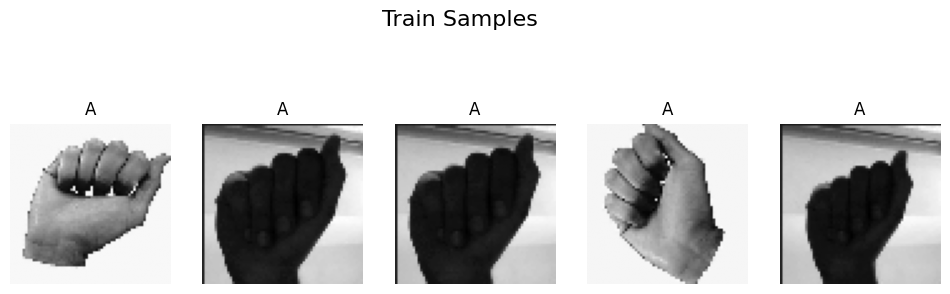

In [ ]:
import matplotlib.pyplot as plt

def show_samples(X, y, classes, n=5, title="Samples"):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(X[i].squeeze(), cmap="gray")  # squeeze() لو الصور grayscale
        # Decode the one-hot encoded label back to an integer index
        class_index = np.argmax(y[i])
        plt.title(classes[class_index])
        plt.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.show()

# عرض عينات من Train
show_samples(X_train, y_train, classes, n=5, title="Train Samples")